In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
12.8
NVIDIA GeForce RTX 5060 Laptop GPU


In [2]:
import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, recall_score, accuracy_score, classification_report
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          EarlyStoppingCallback, TrainerCallback, set_seed)


print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128 | cuda: True
gpu: NVIDIA GeForce RTX 5060 Laptop GPU


In [3]:
CONFIG = {
    "run_name": "full_weighted_mobile",     # unique name per experiment
    "data_variant": "full",          # "uci" | "uci+synth" (no hard negatives) | "full"
    "use_class_weights": True,

    "model_name": "google/mobilebert-uncased",
    "max_length": 64,
    "lr": 2e-5,
    "epochs": 5,
    "batch_size": 32,
    "warmup_ratio": 0.1,
    "weight_decay": 0.01,
    "early_stop_patience": 2,
    "seed": 42,

    "results_dir": "../results",
    "splits_dir": "../data/processed/splits",
    "model_dir": "../models",
    "holdout_frac": 0.15,          # fraction of template families per class
    "holdout_templates": None,     # or explicit list: ["OTP_12","OTP_13","Bank_9",...]
}

os.makedirs(CONFIG["results_dir"], exist_ok=True)
os.makedirs(CONFIG["splits_dir"], exist_ok=True)
os.makedirs(CONFIG["model_dir"], exist_ok=True)
set_seed(CONFIG["seed"])

LABELS = ["OTP", "Bank", "Promo", "Delivery", "Spam", "Personal"]
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}
CONFIG

{'run_name': 'full_weighted_mobile',
 'data_variant': 'full',
 'use_class_weights': True,
 'model_name': 'google/mobilebert-uncased',
 'max_length': 64,
 'lr': 2e-05,
 'epochs': 5,
 'batch_size': 32,
 'warmup_ratio': 0.1,
 'weight_decay': 0.01,
 'early_stop_patience': 2,
 'seed': 42,
 'results_dir': '../results',
 'splits_dir': '../data/processed/splits',
 'model_dir': '../models',
 'holdout_frac': 0.15,
 'holdout_templates': None}

In [4]:
uci = pd.read_csv("../data/raw/SMSSpamCollection", sep="\t",
                  names=["label", "text"], encoding="utf-8")
uci["label"] = uci["label"].map({"spam": "Spam", "ham": "Personal"})
uci["source"] = "uci"

synthetic = pd.read_csv("../data/processed/v3/synthetic_sms.csv")
synthetic["is_hard"] = synthetic["template_id"].astype(str).str.startswith("Hard_")
if "source" not in synthetic.columns:
    synthetic["source"] = "synthetic"
if "is_hard" not in synthetic.columns:
    print("WARNING: no 'is_hard' column -> the no_hard_neg ablation won't be able to run")
    synthetic["is_hard"] = False
if "template_id" not in synthetic.columns:
    print("WARNING: no 'template_id' column -> falling back to plain stratified split (no template holdout)")

keep_cols = [c for c in ["text", "label", "source", "is_hard", "template_id"] if c in synthetic.columns]
uci["is_hard"] = False

df = pd.concat([uci[["text", "label", "source", "is_hard"]], synthetic[keep_cols]], ignore_index=True)
df = df.dropna(subset=["text", "label"]).drop_duplicates(subset=["text"]).reset_index(drop=True)
df["label_id"] = df["label"].map(label2id)
assert df["label_id"].notna().all(), "labels outside the 6 known classes found"


print(df.shape)
print(df["label"].value_counts())
df.head()

(14680, 6)
label
Personal    4815
Promo       2515
Bank        2379
OTP         2332
Delivery    1583
Spam        1056
Name: count, dtype: int64


,text,label,source,is_hard,template_id,label_id
0,"Go until jurong point, crazy.. Available only ...",Personal,uci,False,NaN,5
1,Ok lar... Joking wif u oni...,Personal,uci,False,NaN,5
2,Free entry in 2 a wkly comp to win FA Cup fina...,Spam,uci,False,NaN,4
3,U dun say so early hor... U c already then say...,Personal,uci,False,NaN,5
4,"Nah I don't think he goes to usf, he lives aro...",Personal,uci,False,NaN,5


In [5]:
split_files = {s: os.path.join(CONFIG["splits_dir"], f"{s}.csv")
               for s in ["train", "val", "test", "holdout"]}

if all(os.path.exists(p) for p in split_files.values()):
    train_full = pd.read_csv(split_files["train"])
    val_df     = pd.read_csv(split_files["val"])
    test_df    = pd.read_csv(split_files["test"])
    holdout_df = pd.read_csv(split_files["holdout"])
    print("Loaded existing splits (fixed across all runs)")
else:
    assert "template_id" in df.columns and df["template_id"].notna().any(), \
        "template-holdout strategy requires template_id on synthetic rows"

    synth = df[df["template_id"].notna()]
    if CONFIG["holdout_templates"]:
        holdout_fams = set(CONFIG["holdout_templates"])
    else:
        rng = np.random.default_rng(CONFIG["seed"])
        holdout_fams = set()
        for lbl, grp in synth.groupby("label"):          # per-class sampling
            fams = grp["template_id"].unique()
            k = max(1, int(round(CONFIG["holdout_frac"] * len(fams))))
            holdout_fams |= set(rng.choice(fams, size=k, replace=False))

    holdout_df = df[df["template_id"].isin(holdout_fams)].copy()
    pool       = df[~df["template_id"].isin(holdout_fams)].copy()   # UCI rows have NaN -> stay in pool

    train_full, tmp = train_test_split(pool, test_size=0.30,
                                       stratify=pool["label_id"], random_state=CONFIG["seed"])
    val_df, test_df = train_test_split(tmp, test_size=0.50,
                                       stratify=tmp["label_id"], random_state=CONFIG["seed"])

    for name, frame in [("train", train_full), ("val", val_df),
                        ("test", test_df), ("holdout", holdout_df)]:
        frame.to_csv(split_files[name], index=False)
    print(f"Created splits. Held-out families ({len(holdout_fams)}):", sorted(holdout_fams))

print(f"train={len(train_full)}  val={len(val_df)}  test={len(test_df)}  HOLDOUT={len(holdout_df)}")
print("holdout class coverage:\n", holdout_df["label"].value_counts())

Loaded existing splits (fixed across all runs)
train=9097  val=1949  test=1950  HOLDOUT=1684
holdout class coverage:
 label
OTP         461
Promo       404
Delivery    317
Bank        305
Spam        101
Personal     96
Name: count, dtype: int64


In [6]:
v = CONFIG["data_variant"]
if v == "uci":
    train_df = train_full[train_full["source"] == "uci"].copy()
elif v == "uci+synth":
    train_df = train_full[~train_full["is_hard"].fillna(False).astype(bool)].copy()
elif v == "full":
    train_df = train_full.copy()
else:
    raise ValueError(v)

print(f"variant='{v}'  ->  train={len(train_df)} (val/test unchanged)")
print(train_df["label"].value_counts())

variant='full'  ->  train=9097 (val/test unchanged)
label
Personal    3303
Promo       1478
Bank        1452
OTP         1310
Delivery     886
Spam         668
Name: count, dtype: int64


In [7]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

sample = train_df.groupby("label").sample(3, random_state=0)
for _, row in sample.iterrows():
    ids = tokenizer(row["text"], truncation=True, max_length=CONFIG["max_length"])["input_ids"]
    print(f"[{row['label']:>8}] {row['text'][:70]}")
    print(f"          -> {tokenizer.convert_ids_to_tokens(ids)[:18]}\n")

config.json:   0%|          | 0.00/847 [00:00<?, ?B/s]

c:\Users\Shashikanth\anaconda3\envs\smartsms\lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Shashikanth\.cache\huggingface\hub\models--google--mobilebert-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[    Bank] Rs.21393 credited to A/c XX4136 on 07-06-26. Avl Bal: Rs.387760. -SBI
          -> ['[CLS]', 'rs', '.', '213', '##9', '##3', 'credited', 'to', 'a', '/', 'c', 'xx', '##41', '##36', 'on', '07', '-', '06']

[    Bank] UPI PAYMENT OF RS.89574 TO AYUSH SUCCESSFUL. UPI REF: 679122068190. -B
          -> ['[CLS]', 'up', '##i', 'payment', 'of', 'rs', '.', '89', '##57', '##4', 'to', 'a', '##yu', '##sh', 'successful', '.', 'up', '##i']

[    Bank] EMI of Rs.54051 due on 25-01-26 for loan A/c XX1482 Pay now to avoid c
          -> ['[CLS]', 'emi', 'of', 'rs', '.', '540', '##51', 'due', 'on', '25', '-', '01', '-', '26', 'for', 'loan', 'a', '/']

[Delivery] Delivered! Your Swiggy order OD8658924839 was delivered on 02 Jul. Rat
          -> ['[CLS]', 'delivered', '!', 'your', 'sw', '##ig', '##gy', 'order', 'o', '##d', '##86', '##58', '##9', '##24', '##8', '##39', 'was', 'delivered']

[Delivery] Order OD5613779575 packed and ready! Expected dispatch by 05 Jul. -Fli
          -> ['[CLS]', '

token length p50=25  p95=45  p99=60  max=221
share truncated at max_length=64: 0.6376%
[UNK] rate: 0.00128%  (should be ~0)


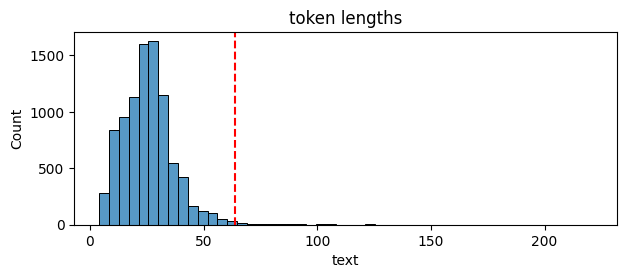

In [8]:
tok_lens = train_df["text"].apply(lambda t: len(tokenizer(t)["input_ids"]))
unk_id = tokenizer.unk_token_id
unk_rate = train_df["text"].apply(lambda t: tokenizer(t)["input_ids"].count(unk_id)).sum() / tok_lens.sum()

print(f"token length p50={tok_lens.quantile(.5):.0f}  p95={tok_lens.quantile(.95):.0f}  p99={tok_lens.quantile(.99):.0f}  max={tok_lens.max()}")
print(f"share truncated at max_length={CONFIG['max_length']}: {(tok_lens > CONFIG['max_length']).mean():.4%}")
print(f"[UNK] rate: {unk_rate:.5%}  (should be ~0)")

plt.figure(figsize=(7,2.5)); sns.histplot(tok_lens, bins=50)
plt.axvline(CONFIG["max_length"], color="red", ls="--"); plt.title("token lengths"); plt.show()

In [9]:
for _, r in train_df.sample(10, random_state=1).iterrows():
    print(f"id={r['label_id']} label={r['label']:>8} | {r['text'][:80]}")

id=5 label=Personal | A famous quote : when you develop the ability to listen to 'anything' unconditio
id=0 label=     OTP | flipkart: 192429 is your login otp. it expires in 2 minutes.
id=0 label=     OTP | 405087  - use this to sign in. Never share this code with anyone.
id=0 label=     OTP | 233953 is your OTP for ICICI Bank login. Valid for 30 minutes. Do not share with
id=2 label=   Promo | Data exhausted? Get 1.5GB extra with Rs.1422 booster pack. Dial *121# or visit a
id=0 label=     OTP | <#> 94907 is your Meesho code Valid 15 min hA8sk2Lqp3
id=1 label=    Bank | Auto-pay of Rs.10226 to Bhavna is scheduled on 03-07-26 from A/c XX9443. Ensure 
id=2 label=   Promo | Last day! BigBasket clearance sale ends tonight. Up to 80% off sitewide.
id=5 label=Personal | So wats ur opinion abt him and how abt is character?
id=5 label=Personal | Wat time ü finish?


In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
tiny = train_df.sample(32, random_state=0)
enc = tokenizer(list(tiny["text"]), truncation=True, max_length=CONFIG["max_length"],
                padding=True, return_tensors="pt").to(device)
y = torch.tensor(tiny["label_id"].values, device=device)

# m = AutoModelForSequenceClassification.from_pretrained(CONFIG["model_name"], num_labels=len(LABELS)).to(device)
# opt = torch.optim.AdamW(m.parameters(), lr=5e-5)
# m.train()
# for step in range(60):
#     opt.zero_grad()
#     out = m(**enc, labels=y)
#     out.loss.backward(); opt.step()
#     if step % 10 == 0 or step == 59:
#         acc = (out.logits.argmax(-1) == y).float().mean().item()
#         print(f"step {step:3d}  loss={out.loss.item():.4f}  acc={acc:.2%}")

# assert out.loss.item() < 0.05, "Pipeline failed to overfit 32 samples -> there is a bug, do NOT proceed"
# del m, opt; torch.cuda.empty_cache()
# print("\nPASS - pipeline can memorize. Safe to train for real.")

m = AutoModelForSequenceClassification.from_pretrained(CONFIG["model_name"], num_labels=len(LABELS)).to(device)
opt = torch.optim.AdamW(m.parameters(), lr=3e-5)   # ← lower from 5e-5
m.train()
for step in range(200):                             # ← more steps, MobileBERT needs them
    opt.zero_grad()
    out = m(**enc, labels=y)
    out.loss.backward()
    torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)   # ← add gradient clipping
    opt.step()
    if step % 10 == 0 or step == 99:
        acc = (out.logits.argmax(-1) == y).float().mean().item()
        print(f"step {step:3d}  loss={out.loss.item():.4f}  acc={acc:.2%}")

Loading weights:   0%|          | 0/1111 [00:00<?, ?it/s]

[transformers] MobileBertForSequenceClassification LOAD REPORT from: google/mobilebert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.dense.weight               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architect

step   0  loss=8252078.0000  acc=12.50%
step  10  loss=997110.0000  acc=12.50%
step  20  loss=2723.8682  acc=21.88%
step  30  loss=2.3165  acc=31.25%
step  40  loss=0.7220  acc=78.12%
step  50  loss=0.1006  acc=100.00%
step  60  loss=0.0011  acc=100.00%
step  70  loss=0.0001  acc=100.00%
step  80  loss=0.0000  acc=100.00%
step  90  loss=0.0000  acc=100.00%
step  99  loss=0.0000  acc=100.00%
step 100  loss=0.0000  acc=100.00%
step 110  loss=0.0000  acc=100.00%
step 120  loss=0.0000  acc=100.00%
step 130  loss=0.0000  acc=100.00%
step 140  loss=0.0000  acc=100.00%
step 150  loss=0.0000  acc=100.00%
step 160  loss=0.0000  acc=100.00%
step 170  loss=0.0000  acc=100.00%
step 180  loss=0.0000  acc=100.00%
step 190  loss=0.0000  acc=100.00%


In [14]:
def to_ds(frame):
    ds = Dataset.from_pandas(frame[["text", "label_id"]].rename(columns={"label_id": "labels"}),
                             preserve_index=False)
    return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=CONFIG["max_length"]),
                  batched=True, remove_columns=["text"])

train_ds, val_ds, test_ds,holdout_ds = to_ds(train_df), to_ds(val_df), to_ds(test_df), to_ds(holdout_df)
collator = DataCollatorWithPadding(tokenizer)

if CONFIG["use_class_weights"]:
    present = np.unique(train_df["label_id"].values)
    w_present = compute_class_weight("balanced", classes=present, y=train_df["label_id"].values)
    w = np.ones(len(LABELS))
    w[present] = w_present
    class_weights = torch.tensor(w, dtype=torch.float32)
    print("class weights:", dict(zip(LABELS, np.round(w, 3))))
    missing = set(range(len(LABELS))) - set(present)
    if missing:
        print("NOTE: no training samples for:", [LABELS[i] for i in missing], "- weight defaulted to 1.0")
else:
    class_weights = None
    print("plain (unweighted) cross-entropy")
    
    
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"], num_labels=len(LABELS), id2label=id2label, label2id=label2id)

Map:   0%|          | 0/9097 [00:00<?, ? examples/s]

Map:   0%|          | 0/1949 [00:00<?, ? examples/s]

Map:   0%|          | 0/1950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1684 [00:00<?, ? examples/s]

class weights: {'OTP': np.float64(1.157), 'Bank': np.float64(1.044), 'Promo': np.float64(1.026), 'Delivery': np.float64(1.711), 'Spam': np.float64(2.27), 'Personal': np.float64(0.459)}


Loading weights:   0%|          | 0/1111 [00:00<?, ?it/s]

[transformers] MobileBertForSequenceClassification LOAD REPORT from: google/mobilebert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.dense.weight               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architect

In [15]:
class JsonlLogger(TrainerCallback):
    def __init__(self, path):
        self.path = path
        os.makedirs(os.path.dirname(path), exist_ok=True)
        open(path, "w").close()                      # fresh file per run
    def on_log(self, args, state, control, logs=None, **kw):
        if logs:
            rec = {"step": state.global_step, "epoch": state.epoch, "time": time.time(), **logs}
            with open(self.path, "a") as f:
                f.write(json.dumps(rec) + "\n")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        if class_weights is not None:
            loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(outputs.logits.device))
        else:
            loss_fct = torch.nn.CrossEntropyLoss()
        loss = loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    out = {"macro_f1": f1_score(labels, preds, average="macro"),
           "otp_recall": recall_score(labels, preds, average=None, labels=range(len(LABELS)))[label2id["OTP"]]}
    for i, name in enumerate(LABELS):
        out[f"f1_{name}"] = f1_score(labels, preds, average=None, labels=range(len(LABELS)))[i]
    return out

log_path = os.path.join(CONFIG["results_dir"], "logs", CONFIG["run_name"] + ".jsonl")

In [16]:
args = TrainingArguments(
    output_dir=os.path.join(CONFIG["model_dir"], CONFIG["run_name"]),
    num_train_epochs=CONFIG["epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=64,
    learning_rate=CONFIG["lr"],
    warmup_ratio=CONFIG["warmup_ratio"],
    lr_scheduler_type="cosine",          # ← LR scheduler: cosine decay after warmup
    max_grad_norm=1.0,                   # ← gradient clipping (the MobileBERT stability fix)
    weight_decay=CONFIG["weight_decay"],
    bf16=torch.cuda.is_available(),
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=50,
    seed=CONFIG["seed"],
    report_to="none",
)

trainer = WeightedTrainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    data_collator=collator, compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG["early_stop_patience"]),
               JsonlLogger(log_path)],
)

train_result = trainer.train()
print(train_result.metrics)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Macro F1,Otp Recall,F1 Otp,F1 Bank,F1 Promo,F1 Delivery,F1 Spam,F1 Personal
1,0.422530,452.611450,0.979532,1.000000,0.998217,0.993610,0.995276,1.000000,0.909091,0.980999
2,0.013311,37.542603,0.989919,1.000000,0.998217,0.996795,1.000000,1.000000,0.954386,0.990113
3,0.024597,111.657257,0.990737,1.000000,0.998217,0.996795,1.000000,1.000000,0.958621,0.990787
4,0.017247,26.256590,0.992944,1.000000,1.000000,0.996795,1.000000,1.000000,0.968641,0.992226
5,0.026659,16.062996,0.992944,1.000000,1.000000,0.996795,1.000000,1.000000,0.968641,0.992226


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': 241.3734, 'train_samples_per_second': 188.442, 'train_steps_per_second': 5.904, 'total_flos': 297970381157904.0, 'train_loss': 203555.41504935778, 'epoch': 5.0}


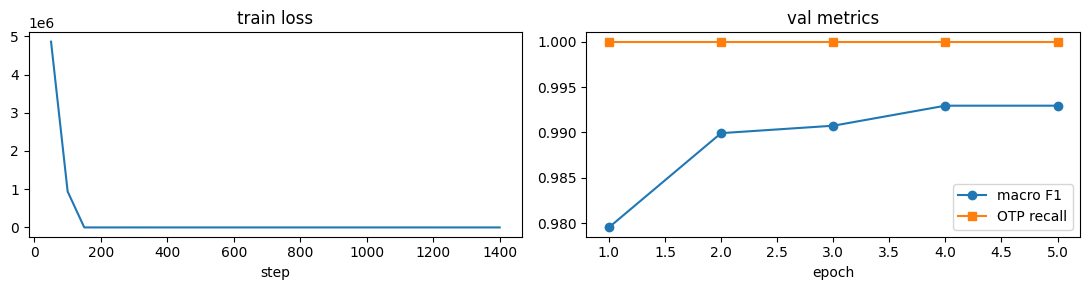

In [17]:
logs = pd.DataFrame([json.loads(l) for l in open(log_path)])
tr = logs.dropna(subset=["loss"]) if "loss" in logs else pd.DataFrame()
ev = logs.dropna(subset=["eval_macro_f1"]) if "eval_macro_f1" in logs else pd.DataFrame()

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
if len(tr): ax[0].plot(tr["step"], tr["loss"]); ax[0].set_title("train loss"); ax[0].set_xlabel("step")
if len(ev):
    ax[1].plot(ev["epoch"], ev["eval_macro_f1"], marker="o", label="macro F1")
    ax[1].plot(ev["epoch"], ev["eval_otp_recall"], marker="s", label="OTP recall")
    ax[1].set_title("val metrics"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

In [18]:
pred_out = trainer.predict(test_ds)
preds = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids

print(classification_report(y_true, preds, target_names=LABELS, digits=4))

report = classification_report(y_true, preds, target_names=LABELS, output_dict=True)
slices = {}

hard_mask = test_df["is_hard"].fillna(False).astype(bool).values if "is_hard" in test_df else np.zeros(len(test_df), bool)
if hard_mask.any():
    slices["hard_negative_acc"] = float(accuracy_score(y_true[hard_mask], preds[hard_mask]))
    print(f"hard-negative slice ({hard_mask.sum()} samples): acc={slices['hard_negative_acc']:.4f}")

        
# ---- Template-holdout: unseen formats, never touched during training/selection
hold_out = trainer.predict(holdout_ds)
h_preds, h_true = np.argmax(hold_out.predictions, axis=-1), hold_out.label_ids

present = sorted(set(h_true))                     # holdout likely lacks UCI-only classes
print(classification_report(h_true, h_preds,
      labels=present, target_names=[LABELS[i] for i in present], digits=4))

holdout_metrics = {
    "holdout_acc": float(accuracy_score(h_true, h_preds)),
    "holdout_macro_f1": float(f1_score(h_true, h_preds, average="macro", labels=present)),
}
if label2id["OTP"] in present:
    holdout_metrics["holdout_otp_recall"] = float(
        recall_score(h_true, h_preds, average=None, labels=present)[present.index(label2id["OTP"])])
    print(f"holdout OTP recall = {holdout_metrics['holdout_otp_recall']:.4f}")

holdout_metrics["gap"] = float(report["macro avg"]["f1-score"] - holdout_metrics["holdout_macro_f1"])
print(f"\nstandard-test macro F1 = {report['macro avg']['f1-score']:.4f}")
print(f"holdout      macro F1 = {holdout_metrics['holdout_macro_f1']:.4f}   gap = {holdout_metrics['gap']:+.4f}")
print("gap < ~0.03: generalizing | gap large: memorizing template skeletons -> add template diversity")

              precision    recall  f1-score   support

         OTP     0.9929    1.0000    0.9965       281
        Bank     0.9968    1.0000    0.9984       311
       Promo     0.9969    1.0000    0.9984       317
    Delivery     0.9896    1.0000    0.9948       190
        Spam     0.9779    0.9301    0.9534       143
    Personal     0.9929    0.9944    0.9936       708

    accuracy                         0.9928      1950
   macro avg     0.9912    0.9874    0.9892      1950
weighted avg     0.9928    0.9928    0.9927      1950

hard-negative slice (169 samples): acc=1.0000


              precision    recall  f1-score   support

         OTP     0.7764    0.6703    0.7194       461
        Bank     0.4278    0.5049    0.4632       305
       Promo     0.9943    0.8614    0.9231       404
    Delivery     1.0000    1.0000    1.0000       317
        Spam     0.6196    1.0000    0.7652       101
    Personal     1.0000    1.0000    1.0000        96

    accuracy                         0.7868      1684
   macro avg     0.8030    0.8394    0.8118      1684
weighted avg     0.8110    0.7868    0.7934      1684

holdout OTP recall = 0.6703

standard-test macro F1 = 0.9892
holdout      macro F1 = 0.8118   gap = +0.1774
gap < ~0.03: generalizing | gap large: memorizing template skeletons -> add template diversity


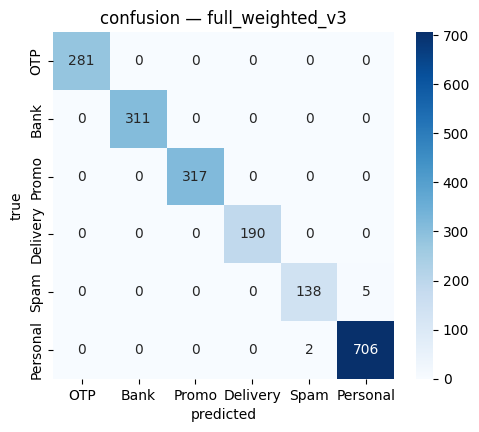

Watch the Bank->OTP cell: those are messages your app would wrongly auto-delete.


In [185]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABELS, yticklabels=LABELS, cmap="Blues")
plt.xlabel("predicted"); plt.ylabel("true"); plt.title(f"confusion — {CONFIG['run_name']}")
plt.show()
print("Watch the Bank->OTP cell: those are messages your app would wrongly auto-delete.")       

In [19]:
result = {
    "run_name": CONFIG["run_name"],
    "config": {k: v for k, v in CONFIG.items() if not k.endswith("_dir")},
    "test_macro_f1": report["macro avg"]["f1-score"],
    "test_accuracy": report["accuracy"],
    "per_class": {l: report[l] for l in LABELS},
    **slices,
    **holdout_metrics,
}
with open(os.path.join(CONFIG["results_dir"], CONFIG["run_name"] + ".json"), "w") as f:
    json.dump(result, f, indent=2)

best_dir = os.path.join(CONFIG["model_dir"], CONFIG["run_name"], "best")
trainer.save_model(best_dir)
tokenizer.save_pretrained(best_dir)
with open(os.path.join(best_dir, "labels.json"), "w") as f:
    json.dump({"labels": LABELS, "label2id": label2id}, f, indent=2)
print("saved:", best_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved: ../models\full_weighted_mobile\best


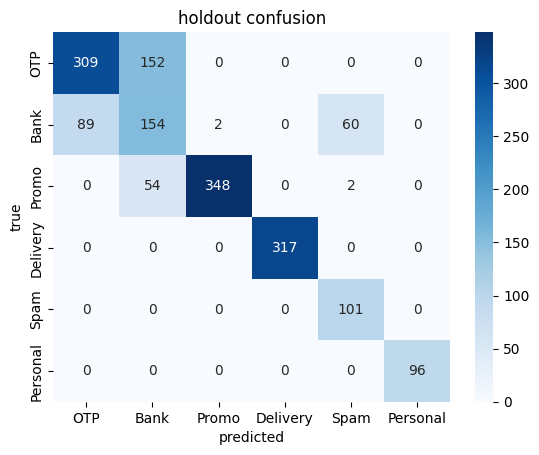

template_id
Promo_14    56
Name: count, dtype: int64
[Promo_14] true=Promo pred=Bank | Pre-approved!  Get a ICICI Bank credit card with Rs.278555 limit. Zero joining fee. Apply:
[Promo_14] true=Promo pred=Bank | Pre-approved! Get a HDFC Bank credit card with Rs.257941 limit. Zero joining fee. Apply: b
[Promo_14] true=Promo pred=Bank | Pre-approved! Get a HDFC Bank credit card with Rs.436263 limit. Zero joining fee. Apply: b
[Promo_14] true=Promo pred=Bank | Pre-approved!  Get a Axis Bank credit card with Rs.455155 limit. Zero joining fee. Apply: 
[Promo_14] true=Promo pred=Bank | Pre-approved! Get a ICICI Bank credit card with INR 413673 limit. Zero joining fee. Apply:
[Promo_14] true=Promo pred=Bank | Pre-approved! Get a PNB credit card with INR 457744 limit. Zero joining fee. Apply: bit.ly
[Promo_14] true=Promo pred=Bank | Pre-approved! Get a HDFC Bank credit card with Rs.447866 limit. Zero joining fee. Apply: b
[Promo_14] true=Promo pred=Bank | Pre-approved! Get a PNB credit card wi

In [20]:
# holdout confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(h_true, h_preds, labels=present)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=[LABELS[i] for i in present],
            yticklabels=[LABELS[i] for i in present], cmap="Blues")
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("holdout confusion"); plt.show()

# read 20 actual Promo misses, grouped by which template family fails
err = holdout_df.reset_index(drop=True).copy()
err["pred"] = [LABELS[i] for i in h_preds]
promo_miss = err[(err["label"] == "Promo") & (err["pred"] != "Promo")]
print(promo_miss["template_id"].value_counts())          # concentrated or spread?
for _, r in promo_miss.head(20).iterrows():
    print(f"[{r['template_id']}] true=Promo pred={r['pred']} | {r['text'][:90]}")

In [188]:
rows = []
for fn in sorted(os.listdir(CONFIG["results_dir"])):
    if fn.endswith(".json"):
        r = json.load(open(os.path.join(CONFIG["results_dir"], fn)))
        rows.append({
            "run": r["run_name"],
            "variant": r["config"].get("data_variant"),
            "weighted": r["config"].get("use_class_weights"),
            "macro_f1": round(r["test_macro_f1"], 4),
            "OTP_f1": round(r["per_class"]["OTP"]["f1-score"], 4),
            "OTP_recall": round(r["per_class"]["OTP"]["recall"], 4),
            "Bank_f1": round(r["per_class"]["Bank"]["f1-score"], 4),
            "hard_neg_acc": round(r["hard_negative_acc"], 4) if "hard_negative_acc" in r else None,
            "holdout_f1": round(r["holdout_macro_f1"], 4) if "holdout_macro_f1" in r else None,
            "holdout_otp_rec": round(r["holdout_otp_recall"], 4) if "holdout_otp_recall" in r else None,
            "gap": round(r["gap"], 4) if "gap" in r else None,
        })
pd.DataFrame(rows).sort_values("macro_f1", ascending=False)

,run,variant,weighted,macro_f1,OTP_f1,OTP_recall,Bank_f1,hard_neg_acc,holdout_f1,holdout_otp_rec,gap
1,full_weighted,full,True,0.9958,1.0000,1.0000,1.0000,1.0000,0.9021,1.0000,0.0937
3,full_weighted_v3,full,True,0.9951,1.0000,1.0000,1.0000,1.0000,0.7039,0.6703,0.2912
0,full_plain_CE,full,False,0.9930,1.0000,1.0000,1.0000,1.0000,0.8822,1.0000,0.1108
2,full_weighted_v2,full,True,0.9896,1.0000,1.0000,1.0000,1.0000,0.6599,0.9875,0.3297
4,no_hard_neg,uci+synth,True,0.9320,0.9529,0.9965,0.9713,0.4676,0.8330,0.9925,0.0990
5,uci_only,uci,True,0.1979,0.0000,0.0000,0.0000,0.3669,0.1640,0.0000,0.0339


In [ ]:
    
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"], num_labels=len(LABELS), id2label=id2label, label2id=label2id)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
best_dir = os.path.join(CONFIG["model_dir"], "full_weighted", "best")
model = AutoModelForSequenceClassification.from_pretrained(best_dir)
tokenizer = AutoTokenizer.from_pretrained(best_dir)

trainer = Trainer(          # plain Trainer is fine — no training, so no weighted loss needed
    model=model,
    args=TrainingArguments(output_dir="tmp_eval", per_device_eval_batch_size=64,
                           bf16=torch.cuda.is_available(), report_to="none"),
    data_collator=collator,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
pred_out = trainer.predict(test_ds)
preds = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids

print(classification_report(y_true, preds, target_names=LABELS, digits=4))

report = classification_report(y_true, preds, target_names=LABELS, output_dict=True)
slices = {}

hard_mask = test_df["is_hard"].fillna(False).astype(bool).values if "is_hard" in test_df else np.zeros(len(test_df), bool)
if hard_mask.any():
    slices["hard_negative_acc"] = float(accuracy_score(y_true[hard_mask], preds[hard_mask]))
    print(f"hard-negative slice ({hard_mask.sum()} samples): acc={slices['hard_negative_acc']:.4f}")

        
# ---- Template-holdout: unseen formats, never touched during training/selection
hold_out = trainer.predict(holdout_ds)
h_preds, h_true = np.argmax(hold_out.predictions, axis=-1), hold_out.label_ids

present = sorted(set(h_true))                     # holdout likely lacks UCI-only classes
print(classification_report(h_true, h_preds,
      labels=present, target_names=[LABELS[i] for i in present], digits=4))

holdout_metrics = {
    "holdout_acc": float(accuracy_score(h_true, h_preds)),
    "holdout_macro_f1": float(f1_score(h_true, h_preds, average="macro", labels=present)),
}
if label2id["OTP"] in present:
    holdout_metrics["holdout_otp_recall"] = float(
        recall_score(h_true, h_preds, average=None, labels=present)[present.index(label2id["OTP"])])
    print(f"holdout OTP recall = {holdout_metrics['holdout_otp_recall']:.4f}")

holdout_metrics["gap"] = float(report["macro avg"]["f1-score"] - holdout_metrics["holdout_macro_f1"])
print(f"\nstandard-test macro F1 = {report['macro avg']['f1-score']:.4f}")
print(f"holdout      macro F1 = {holdout_metrics['holdout_macro_f1']:.4f}   gap = {holdout_metrics['gap']:+.4f}")
print("gap < ~0.03: generalizing | gap large: memorizing template skeletons -> add template diversity")

              precision    recall  f1-score   support

         OTP     1.0000    1.0000    1.0000       284
        Bank     1.0000    1.0000    1.0000       279
       Promo     1.0000    1.0000    1.0000       211
    Delivery     1.0000    1.0000    1.0000       197
        Spam     0.9929    0.9655    0.9790       145
    Personal     0.9930    0.9986    0.9958       707

    accuracy                         0.9967      1823
   macro avg     0.9976    0.9940    0.9958      1823
weighted avg     0.9967    0.9967    0.9967      1823

hard-negative slice (139 samples): acc=1.0000


              precision    recall  f1-score   support

         OTP     1.0000    1.0000    1.0000       399
        Bank     1.0000    0.8996    0.9472       279
       Promo     1.0000    0.6139    0.7608       259
    Delivery     0.7468    1.0000    0.8551       295
        Spam     0.7383    1.0000    0.8495        79
    Personal     1.0000    1.0000    1.0000        96

    accuracy                         0.9090      1407
   macro avg     0.9142    0.9189    0.9021      1407
weighted avg     0.9322    0.9090    0.9066      1407

holdout OTP recall = 1.0000

standard-test macro F1 = 0.9958
holdout      macro F1 = 0.9021   gap = +0.0937
gap < ~0.03: generalizing | gap large: memorizing template skeletons -> add template diversity


In [ ]:
err = holdout_df.reset_index(drop=True).copy()
err["pred"] = [LABELS[i] for i in h_preds]

for cls in ["Promo", "Bank"]:
    miss = err[(err["label"] == cls) & (err["pred"] != cls)]
    print(f"\n=== {cls} misses: {len(miss)} ===")
    print(miss["template_id"].value_counts())
    for _, r in miss.head(10).iterrows():
        print(f"[{r['template_id']}] pred={r['pred']} | {r['text'][:90]}")


=== Promo misses: 100 ===
template_id
Hard_1    100
Name: count, dtype: int64
[Hard_1] pred=Delivery | Coupon 2685 gives you free delivery on orders above Rs.4403. -Flipkart
[Hard_1] pred=Delivery | coupon 4704 gives you free delivery on orders above rs.4536. -meesho
[Hard_1] pred=Delivery | Coupon 6360 gives you free delivery on orders above Rs.4298. -Flipkart
[Hard_1] pred=Delivery | Coupon 1915 gives you free delivery on orders above INR 1829. -Flipkart
[Hard_1] pred=Delivery | COUPON 6693 GIVES YOU FREE DELIVERY ON ORDERS ABOVE RS.2869. -ZOMATO
[Hard_1] pred=Delivery | Coupon  9823 gives you free delivery on orders above Rs.3694. -Zomato
[Hard_1] pred=Delivery | Coupon 5794 gives you free delivery on orders above Rs.3522. -Swiggy T&C apply
[Hard_1] pred=Delivery | coupon 7642 gives you free delivery on orders above rs.3195. -swiggy
[Hard_1] pred=Delivery | Coupon 8616 gives you free delivery on orders above Rs.3505. -Myntra
[Hard_1] pred=Delivery |   Coupon 4283 gives you free del

# for conversion

In [1]:
import torch, ai_edge_torch, transformers
print(torch.__version__)          # expect a CPU build, e.g. no +cu suffix
from transformers import AutoModelForSequenceClassification
m = AutoModelForSequenceClassification.from_pretrained("../models/full_weighted/best")
print("checkpoint loads OK")

ModuleNotFoundError: No module named 'torch_xla'